### Building a Basic Chatbot with Langgraph(Graph Api)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class state(TypedDict):
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(state)

In [4]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [5]:
# node functionality
def chatbot(state:state):
    return {'messages':[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(state)

#addding node to the graph
graph_builder.add_node("llmchatbot", chatbot)

#adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

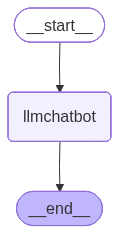

In [7]:
#visualization graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response = graph.invoke({"messages":"hi"})

In [9]:
for event in graph.stream({"messages":"hi, how are you today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [10]:
# To install: pip install tavily-python
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(max_result=2)
tavily_search.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to 

In [11]:
## custom tool function
from langchain_core.tools import tool

@tool
def multipl(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


In [12]:
tools = [tavily_search, multipl]

In [13]:
llm_with_tools = llm.bind_tools(tools)

In [14]:
for t in tools:
    print(t)

api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)
name='multipl' description='Multiply two integers.' args_schema=<class 'langchain_core.utils.pydantic.multipl'> func=<function multipl at 0x00000218C58E24B0>


In [15]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000218C59786E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000218C5979160>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [16]:
for t in tools:
    print(t.name)

tavily_search
multipl


In [17]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #"if the latest message (result) from assisant is tool calling -> tool_conditons routes to tools"
    #"if the latest message (result) from assisant is not tool calling -> conditons routes to END"
    tools_condition
)

builder.add_edge("tools",END)

# compile the graph
graph = builder.compile()

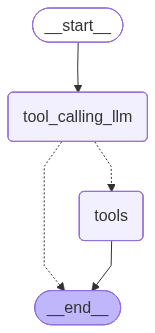

In [18]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"what is the recent ai news"})
response

{'messages': [HumanMessage(content='what is the recent ai news', additional_kwargs={}, response_metadata={}, id='93acd8a8-5623-4743-9cd8-075a99e47dfc'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd1wnrh0j8', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1741, 'total_tokens': 1772, 'completion_time': 0.105747203, 'completion_tokens_details': None, 'prompt_time': 0.11419358, 'prompt_tokens_details': None, 'queue_time': 0.325205479, 'total_time': 0.219940783}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_ce7bc1685b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef38a-39a3-7cb2-82c5-e621340cbda0-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'time_range': 'day', 'topic': 'ne

In [58]:
response = graph.invoke({"messages":"what is the 2 * 3"})
response

{'messages': [HumanMessage(content='what is the 2 * 3', additional_kwargs={}, response_metadata={}, id='633fe587-33a5-4097-80f2-8f50eb0806da'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'c554dvfyk', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1743, 'total_tokens': 1763, 'completion_time': 0.060267906, 'completion_tokens_details': None, 'prompt_time': 0.090863479, 'prompt_tokens_details': None, 'queue_time': 0.056558441, 'total_time': 0.151131385}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee980-dd05-7e03-b2af-a14f1093b76f-0', tool_calls=[{'name': 'multipl', 'args': {'a': 2, 'b': 3}, 'id': 'c554dvfyk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output

In [59]:
response = graph.invoke({"messages":"what is the 10 + 3"})
response

{'messages': [HumanMessage(content='what is the 10 + 3', additional_kwargs={}, response_metadata={}, id='ca662531-9728-4246-b89e-c6e63762a049'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yyhy338qn', 'function': {'arguments': '{"a":10,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1743, 'total_tokens': 1763, 'completion_time': 0.048240375, 'completion_tokens_details': None, 'prompt_time': 0.085755, 'prompt_tokens_details': None, 'queue_time': 0.162177779, 'total_time': 0.133995375}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee981-2b5e-7041-8dff-4676705c3129-0', tool_calls=[{'name': 'multipl', 'args': {'a': 10, 'b': 3}, 'id': 'yyhy338qn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output

In [76]:
response = graph.invoke({"messages":"what is the current ai development"})
response

{'messages': [HumanMessage(content='what is the current ai development', additional_kwargs={}, response_metadata={}, id='0f74c6d6-88a0-4986-a174-5ad00a324e5c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6djwgt9vd', 'function': {'arguments': '{"query":"current AI development","search_depth":"advanced","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1741, 'total_tokens': 1772, 'completion_time': 0.084074185, 'completion_tokens_details': None, 'prompt_time': 0.104491845, 'prompt_tokens_details': None, 'queue_time': 0.052341615, 'total_time': 0.18856603}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee98a-b152-7ae2-8028-e0cc0a7267ee-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI development',

In [61]:
response = graph.invoke({"messages":"give me recent ai news and 2 * 3"})
response

{'messages': [HumanMessage(content='give me recent ai news and 2 * 3', additional_kwargs={}, response_metadata={}, id='5e5a65e2-dab2-4ba0-8185-69f4d48090a7'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dmerghnfw', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'ygctvhajz', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 1746, 'total_tokens': 1796, 'completion_time': 0.123426488, 'completion_tokens_details': None, 'prompt_time': 0.094821888, 'prompt_tokens_details': None, 'queue_time': 0.162080612, 'total_time': 0.218248376}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee984-09a6-7f72-b287-facc561f6529-

### Adding Memory to Agentic Graph

In [20]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## node defination
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #"if the latest message (result) from assisant is tool calling -> tool_conditons routes to tools"
    #"if the latest message (result) from assisant is not tool calling -> conditons routes to END"
    tools_condition
)

builder.add_edge("tools",END)

# compile the graph
graph = builder.compile(checkpointer=memory)

In [21]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"hi my name is devendra chavan"}, config=config)
response

{'messages': [HumanMessage(content='hi my name is devendra chavan', additional_kwargs={}, response_metadata={}, id='ae8b7c71-4d00-442e-a0f3-413fa2758361'),
  AIMessage(content="Hello Devendra Chavan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1743, 'total_tokens': 1772, 'completion_time': 0.085831447, 'completion_tokens_details': None, 'prompt_time': 0.145546222, 'prompt_tokens_details': None, 'queue_time': 0.055871875, 'total_time': 0.231377669}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef38a-7774-7f02-9527-30056322fe18-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output_tokens': 29, 'total_tokens': 1772})]}

In [22]:
graph.invoke({"messages":"what is my name"}, config=config)

{'messages': [HumanMessage(content='hi my name is devendra chavan', additional_kwargs={}, response_metadata={}, id='ae8b7c71-4d00-442e-a0f3-413fa2758361'),
  AIMessage(content="Hello Devendra Chavan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1743, 'total_tokens': 1772, 'completion_time': 0.085831447, 'completion_tokens_details': None, 'prompt_time': 0.145546222, 'prompt_tokens_details': None, 'queue_time': 0.055871875, 'total_time': 0.231377669}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef38a-7774-7f02-9527-30056322fe18-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output_tokens': 29, 'total_tokens': 1772}),
  HumanMessage(content='what is my name', additi

### Streaming

#### stream() streams graph execution synchronously, while astream() provides the same functionality asynchronously using async for, making it suitable for FastAPI and production async applications.

In [23]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [25]:
def superbot(state:state):
    return {"messages":[llm.invoke(state['messages'])]}

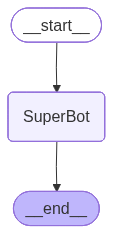

In [31]:
graph = StateGraph(state)

#Add Nodes
graph.add_node("SuperBot", superbot)

#add edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [32]:
## Invocation

config = {'configurable': {"thread_id": "1"}}

graph_builder.invoke({'messages':'hi, my main is devendra chavan and i want to be ai engineer'},config)

{'messages': [HumanMessage(content='hi, my main is devendra chavan and i want to be ai engineer', additional_kwargs={}, response_metadata={}, id='c2d9dae6-bc51-4c6a-b152-fcb84372f64f'),
  AIMessage(content='Nice to meet you, Devendra Chavan. That\'s great to hear that you\'re interested in becoming an AI engineer. AI engineering is a fascinating field that combines computer science, mathematics, and engineering to develop intelligent systems that can think and learn like humans.\n\nTo become an AI engineer, you\'ll need to acquire a strong foundation in:\n\n1. **Programming skills**: Proficiency in languages like Python, Java, C++, and R.\n2. **Mathematics**: Linear algebra, calculus, probability, and statistics.\n3. **Machine learning**: Understanding of supervised, unsupervised, and reinforcement learning techniques.\n4. **Data science**: Knowledge of data structures, data visualization, and data preprocessing.\n5. **Deep learning**: Familiarity with frameworks like TensorFlow, Keras

### Additional paramaters in streaming mode for graph state
- Values: this stream the full state of the graph after each node is called.
- Updates: This streams updates to the state of the graph after each node is called.

In [33]:
# create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"hi my name is devendra chavan and i want to be a ai engineer"}, config=config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Devendra Chavan, it\'s great to meet you. That\'s a fantastic career goal you have - becoming an AI engineer. Artificial Intelligence is a rapidly growing field with immense potential and opportunities.\n\nTo become an AI engineer, you\'ll need to acquire a strong foundation in programming, mathematics, and computer science. Here are some key areas to focus on:\n\n1. **Programming skills**: Proficiency in languages like Python, Java, C++, or R is essential. Python is a popular choice for AI and machine learning.\n2. **Mathematics**: Linear algebra, calculus, probability, and statistics are crucial mathematical concepts for AI.\n3. **Machine learning**: Study machine learning algorithms, including supervised, unsupervised, and reinforcement learning.\n4. **Deep learning**: Familiarize yourself with deep learning frameworks like TensorFlow, Keras, or PyTorch.\n5. **Data structures and algorithms**: Understand data structures like arrays

In [34]:
for chunk in graph_builder.stream({"messages":"hi my name is devendra chavan and i want to be a ai engineer"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is devendra chavan and i want to be a ai engineer', additional_kwargs={}, response_metadata={}, id='44a8f0b7-97df-464e-ae79-5326a011a515'), AIMessage(content='Hello Devendra Chavan, it\'s great to meet you. That\'s a fantastic career goal you have - becoming an AI engineer. Artificial Intelligence is a rapidly growing field with immense potential and opportunities.\n\nTo become an AI engineer, you\'ll need to acquire a strong foundation in programming, mathematics, and computer science. Here are some key areas to focus on:\n\n1. **Programming skills**: Proficiency in languages like Python, Java, C++, or R is essential. Python is a popular choice for AI and machine learning.\n2. **Mathematics**: Linear algebra, calculus, probability, and statistics are crucial mathematical concepts for AI.\n3. **Machine learning**: Study machine learning algorithms, including supervised, unsupervised, and reinforcement learning.\n4. **Deep learning**: Famil

In [ ]:
# create a thread
config = {"configurable": {"thread_id":"4"}}

for chunk in graph_builder.astream_events({"messages":"hi my name is devendra chavan and i want to be a ai engineer"}, config=config, stream_mode="updates"):
    print(chunk)

### Human in the Loop

In [56]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [62]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000218C8863C50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000218C8A0C7D0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [57]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver

from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages : Annotated[list, add_messages]

graph_builder2 = StateGraph(State)

@tool
def human_assis(query: str) -> str:
    """Request assistant from a human"""
    human_response = interrupt({"query": query})
    return human_response["data"]

tool = TavilySearch(max_results=2)
tools = [tool, human_assis]
llm_with_tools2 = llm.bind_tools(tools)

def chatbot(state: State):
    message = llm_with_tools2.invoke(state["messages"])
    # because we will be interrupted during tool execution, we disable  parellel 
    # tool calling to avoid repeated any tool invocation we resume.

    return {"messages": [message]}

graph_builder2.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder2.add_node("tools", tool_node)

graph_builder2.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder2.add_edge("tools", "chatbot")
graph_builder2.add_edge(START, "chatbot")



In [58]:
memory = MemorySaver()

graph = graph_builder2.compile(checkpointer=memory)

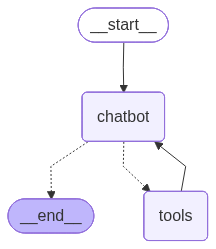

In [59]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [60]:
user_input = "I need some expert guidance and assistance for building an ai agent. could you request assistance for me?"

config = {"configurable": {"thread_id": "5"}}

events = graph.stream(
    {
        "messages": user_input},
        config=config,
        stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an ai agent. could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assis (rvzktjmrj)
 Call ID: rvzktjmrj
  Args:
    query: building an ai agent guidance and assistance
================================== Ai Message ==================================
Tool Calls:
  human_assis (rvzktjmrj)
 Call ID: rvzktjmrj
  Args:
    query: building an ai agent guidance and assistance


In [61]:
human_response = (
    "we, the expert are here to help, we recommend you to check out langgraph to build your agent."
    "it is much more reliable and extensible than simple autonomous agents"
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assis (rvzktjmrj)
 Call ID: rvzktjmrj
  Args:
    query: building an ai agent guidance and assistance
================================= Tool Message =================================
Name: human_assis

we, the expert are here to help, we recommend you to check out langgraph to build your agent.it is much more reliable and extensible than simple autonomous agents
================================== Ai Message ==================================

Let me know if you need any further assistance or guidance.
